# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [3]:
df.shape[0]

144015

In [4]:
df.info(), df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 144015 entries, 0 to 144014
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Trip ID            144015 non-null  int64
 1   Duration           144015 non-null  int64
 2   Start Date         144015 non-null  str  
 3   Start Station      144015 non-null  str  
 4   Start Terminal     144015 non-null  int64
 5   End Date           144015 non-null  str  
 6   End Station        144015 non-null  str  
 7   End Terminal       144015 non-null  int64
 8   Bike #             144015 non-null  int64
 9   Subscription Type  144015 non-null  str  
 10  Zip Code           137885 non-null  str  
dtypes: int64(5), str(6)
memory usage: 12.1 MB


(None,
              Trip ID       Duration  Start Terminal   End Terminal  \
 count  144015.000000  144015.000000   144015.000000  144015.000000   
 mean   100967.962129    1230.910141       56.925515      56.943548   
 std     56121.284410    6652.962329       17.372388      17.366134   
 min      4069.000000      60.000000        2.000000       2.000000   
 25%     52138.500000     349.000000       50.000000      49.000000   
 50%     99969.000000     531.000000       61.000000      61.000000   
 75%    150090.500000     797.000000       70.000000      70.000000   
 max    198775.000000  722236.000000       83.000000      83.000000   
 
               Bike #  
 count  144015.000000  
 mean      437.029407  
 std       138.076365  
 min         9.000000  
 25%       349.000000  
 50%       446.000000  
 75%       546.000000  
 max       717.000000  )

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [5]:
def clean_colname(s):
    return s.lower().replace(" ", "_").replace("#", "num")
df.columns = [clean_colname(tit) for tit in df.columns]
df.head()


,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


How many types of subscription options are there? What are the different subscription types?

In [6]:
df.subscription_type.unique()

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

What is the frequency of each subscription option?

In [7]:
(sub_type:=df.subscription_type.value_counts())

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

Please plot the frequency of each subscription option with a pie chart:

<Axes: >

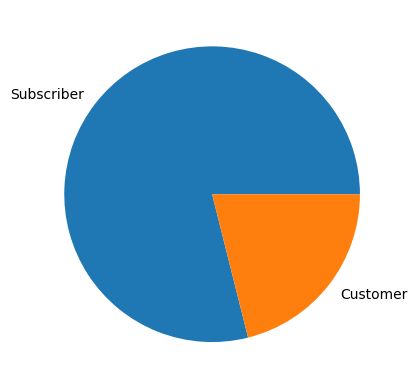

In [8]:
# https://pandas.pydata.org/docs/user_guide/visualization.html
sub_type.plot(kind='pie')

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

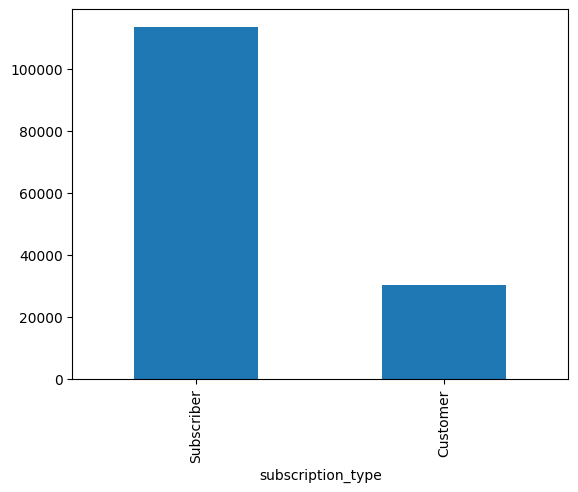

In [9]:
sub_type.plot.bar()

Have a look at the start_station column: Which 10 stations occur most frequently?

In [10]:
df.start_station.value_counts().sort_values(ascending=False)[:10]

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [11]:
df.end_station.value_counts().sort_values(ascending=True)[:10]

end_station
Mezes Park                            5
San Jose Government Center           23
Broadway at Main                     56
San Antonio Shopping Center          93
Franklin at Maple                    93
San Mateo County Center             106
Redwood City Public Library         117
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           205
Name: count, dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [12]:
pd.crosstab(df.subscription_type, df.start_station, margins=True)

start_station,2nd at Folsom,2nd at South Park,2nd at Townsend,5th at Howard,Adobe on Almaden,Arena Green / SAP Center,Beale at Market,Broadway St at Battery St,Broadway at Main,California Ave Caltrain Station,...,South Van Ness at Market,Spear at Folsom,St James Park,Steuart at Market,Temporary Transbay Terminal (Howard at Beale),Townsend at 7th,University and Emerson,Washington at Kearney,Yerba Buena Center of the Arts (3rd @ Howard),All
subscription_type,,,,,,,,,,,,,,,,,,,,,
Customer,427,535,882,606,75,82,457,20,14,161,...,515,416,56,1007,427,518,328,561,628,30368
Subscriber,3349,3923,4105,2029,260,257,2600,181,31,136,...,3006,3007,310,3906,4686,3975,106,911,1859,113647
All,3776,4458,4987,2635,335,339,3057,201,45,297,...,3521,3423,366,4913,5113,4493,434,1472,2487,144015


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [13]:
df.duration.describe()

count    144015.000000
mean       1230.910141
std        6652.962329
min          60.000000
25%         349.000000
50%         531.000000
75%         797.000000
max      722236.000000
Name: duration, dtype: float64

In [14]:
df.duration.sort_values(ascending=False) #.value_counts()

80510     722236
93400     619322
20535     597517
119830    586356
43549     429384
           ...  
2925          60
10457         60
98183         60
2887          60
11545         60
Name: duration, Length: 144015, dtype: int64

In [15]:
df.duration.sort_values(ascending=True).value_counts().sort_index()[:30]

duration
60    17
61    11
62     9
63    14
64    12
65    12
66    11
67    14
68     9
69    13
70    16
71    14
72    18
73    15
74    15
75     7
76    11
77    13
78     9
79    18
80    20
81    13
82    12
83    15
84    12
85    14
86    15
87    17
88    23
89    12
Name: count, dtype: int64

In [16]:
print(f"Shortest trip: {df.duration.min()} - Unit is probably 'seconds'")

Shortest trip: 60 - Unit is probably 'seconds'


What do you think is going on with the short trips?

* no idea what the question is?

What is the longest trip?

In [17]:
print(f"Longest trip: {df.duration.max()} seconds (assuming unit is probably 'seconds')")
print(f"Longest trip: {df.duration.max()/3600/24:.2f} days")

Longest trip: 722236 seconds (assuming unit is probably 'seconds')
Longest trip: 8.36 days


How would you define a "long" trip? How many trips are "long" according to your definition?

In [18]:
(sec_per_day := 3600 * 24)

86400

In [19]:
min_duration_for_long_trip = 3600  # longer than 1 hour
print(f"{(df.duration > min_duration_for_long_trip).sum()} trips are 'long' by definition of 'longer than 1 hour'")


5695 trips are 'long' by definition of 'longer than 1 hour'


In [20]:
min_duration_for_long_trip = 3600*4  # longer than 4 hours
print(f"{(df.duration > min_duration_for_long_trip).sum()} trips are 'long' by definition of 'longer than 4 hours'")


1593 trips are 'long' by definition of 'longer than 4 hours'


In [21]:
print(f"{(df.duration > sec_per_day).sum()} trips are 'long' by definition of 'longer than 1 day'")


82 trips are 'long' by definition of 'longer than 1 day'


In [22]:
df.shape

(144015, 11)

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

Plot the duration column.

In [23]:
df.start_date = pd.to_datetime(df.start_date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144015 entries, 0 to 144014
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   trip_id            144015 non-null  int64         
 1   duration           144015 non-null  int64         
 2   start_date         144015 non-null  datetime64[us]
 3   start_station      144015 non-null  str           
 4   start_terminal     144015 non-null  int64         
 5   end_date           144015 non-null  str           
 6   end_station        144015 non-null  str           
 7   end_terminal       144015 non-null  int64         
 8   bike_num           144015 non-null  int64         
 9   subscription_type  144015 non-null  str           
 10  zip_code           137885 non-null  str           
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 12.1 MB


<Axes: >

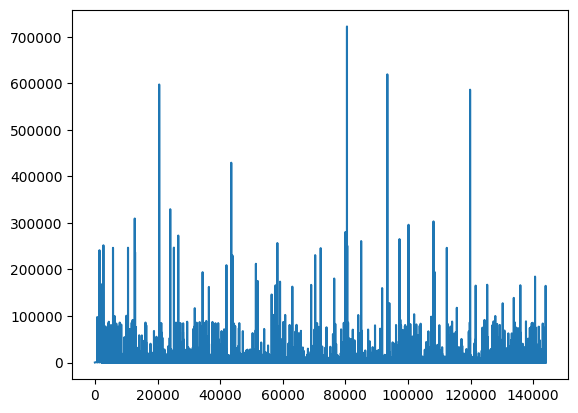

In [24]:
df.duration.plot()

<Axes: xlabel='start_date', ylabel='duration'>

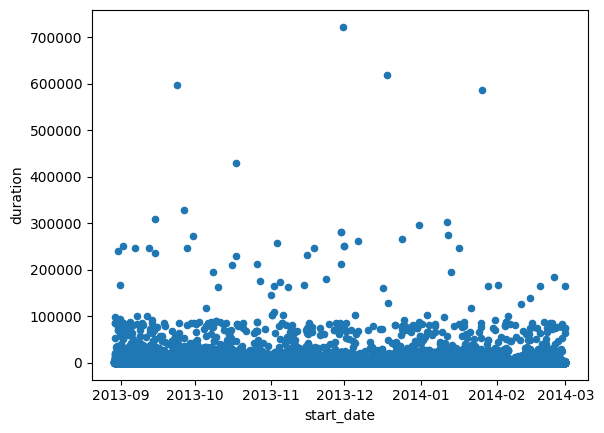

In [25]:
df.plot.scatter(x="start_date", y="duration")

<Axes: ylabel='duration'>

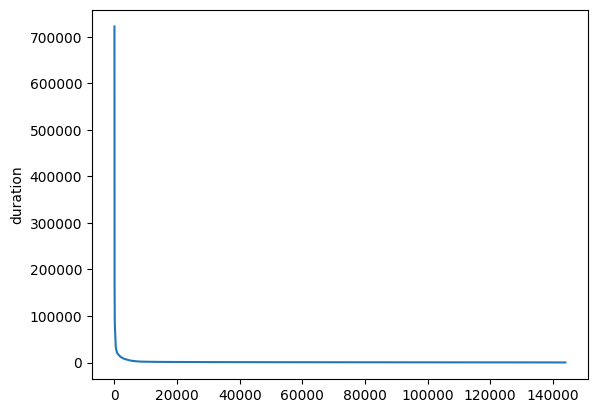

In [26]:
df.duration.sort_values(ascending=False).reset_index(drop=True).plot(ylabel="duration")

<Axes: xlabel='duration', ylabel='Frequency'>

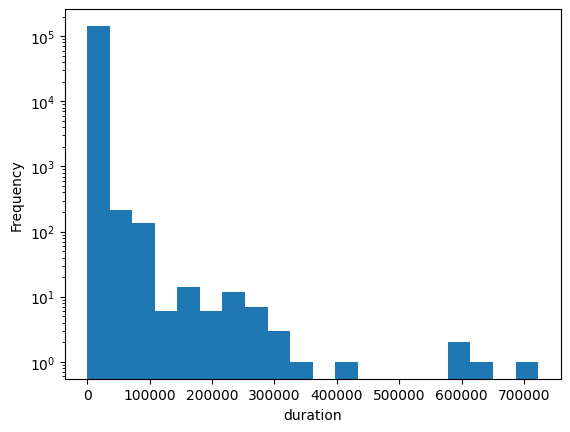

In [27]:
df.duration.plot.hist(bins=20, log=True, xlabel="duration")

Does this plot give any insights?

* not directly

Select subsections of the data to make plots that provide more insights.

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144015 entries, 0 to 144014
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   trip_id            144015 non-null  int64         
 1   duration           144015 non-null  int64         
 2   start_date         144015 non-null  datetime64[us]
 3   start_station      144015 non-null  str           
 4   start_terminal     144015 non-null  int64         
 5   end_date           144015 non-null  str           
 6   end_station        144015 non-null  str           
 7   end_terminal       144015 non-null  int64         
 8   bike_num           144015 non-null  int64         
 9   subscription_type  144015 non-null  str           
 10  zip_code           137885 non-null  str           
dtypes: datetime64[us](1), int64(5), str(5)
memory usage: 12.1 MB


array([[<Axes: xlabel='duration', ylabel='duration'>,
        <Axes: xlabel='end_terminal', ylabel='duration'>,
        <Axes: xlabel='start_terminal', ylabel='duration'>],
       [<Axes: xlabel='duration', ylabel='end_terminal'>,
        <Axes: xlabel='end_terminal', ylabel='end_terminal'>,
        <Axes: xlabel='start_terminal', ylabel='end_terminal'>],
       [<Axes: xlabel='duration', ylabel='start_terminal'>,
        <Axes: xlabel='end_terminal', ylabel='start_terminal'>,
        <Axes: xlabel='start_terminal', ylabel='start_terminal'>]],
      dtype=object)

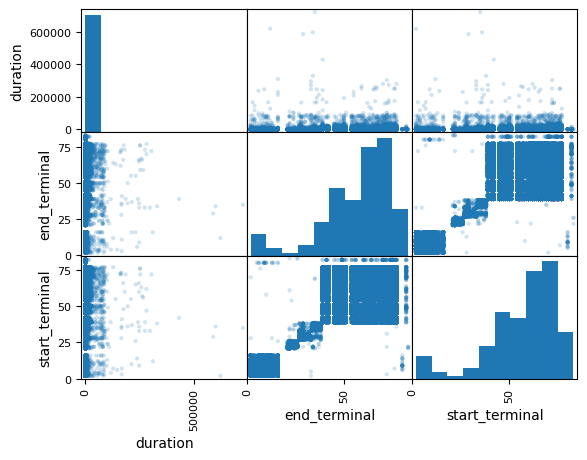

In [48]:
# Note: only works with numerical data
pd.plotting.scatter_matrix(
    df[["duration", "end_terminal", "start_terminal"]],
    alpha=0.2,
)

start_station
2nd at Folsom                                    Axes(0.125,0.11;0.775x0.77)
2nd at South Park                                Axes(0.125,0.11;0.775x0.77)
2nd at Townsend                                  Axes(0.125,0.11;0.775x0.77)
5th at Howard                                    Axes(0.125,0.11;0.775x0.77)
Adobe on Almaden                                 Axes(0.125,0.11;0.775x0.77)
                                                            ...             
Temporary Transbay Terminal (Howard at Beale)    Axes(0.125,0.11;0.775x0.77)
Townsend at 7th                                  Axes(0.125,0.11;0.775x0.77)
University and Emerson                           Axes(0.125,0.11;0.775x0.77)
Washington at Kearney                            Axes(0.125,0.11;0.775x0.77)
Yerba Buena Center of the Arts (3rd @ Howard)    Axes(0.125,0.11;0.775x0.77)
Name: duration, Length: 69, dtype: object

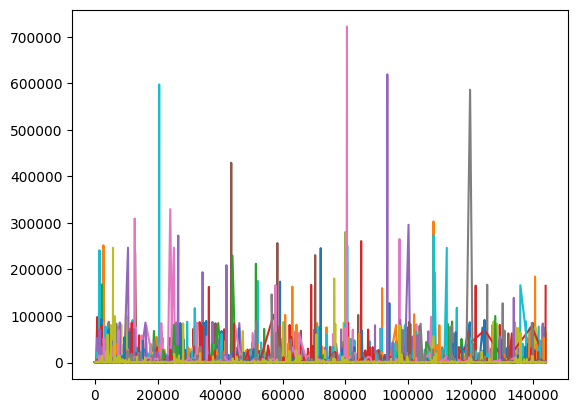

In [29]:
#df.groupby('subscription_type').duration.plot()
df.groupby('start_station').duration.plot()

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [30]:
def clean_station_name(s):
    return s.lower().replace(" ", "_")
df.start_station = df.start_station.apply(clean_station_name)
df.end_station = df.end_station.apply(clean_station_name)
df

,trip_id,duration,start_date,start_station,start_terminal,end_date,end_station,end_terminal,bike_num,subscription_type,zip_code
0,4576,63,2013-08-29 14:13:00,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,2013-08-29 14:42:00,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,2013-08-29 10:16:00,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,2013-08-29 11:29:00,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,2013-08-29 12:02:00,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103
...,...,...,...,...,...,...,...,...,...,...,...
144010,198771,385,2014-02-28 22:15:00,powell_street_bart,39,2/28/2014 22:22,south_van_ness_at_market,66,483,Subscriber,94404
144011,198772,145,2014-02-28 22:38:00,commercial_at_montgomery,45,2/28/2014 22:40,davis_at_jackson,42,425,Subscriber,94111
144012,198773,677,2014-02-28 22:45:00,embarcadero_at_sansome,60,2/28/2014 22:56,market_at_4th,76,438,Subscriber,94102
144013,198774,64128,2014-02-28 23:01:00,civic_center_bart_(7th_at_market),72,3/1/2014 16:50,harry_bridges_plaza_(ferry_building),50,414,Customer,94124


Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 